Install

In [3]:
!pip install wfdb

import wfdb
import os

# Download MIT-BIH dataset
dataset_path = "mitdb"

if not os.path.exists(dataset_path):
    wfdb.dl_database("mitdb", dataset_path)

print("Dataset downloaded.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 34.3 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.
db-dtypes 1.6.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.3 which is incompatible.
Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 

Imports

In [4]:
import numpy as np
import pandas as pd
import wfdb
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import LinearSVC

from sklearn.neighbors import KNeighborsClassifier

from sklearn.tree import DecisionTreeClassifier

from sklearn.neural_network import MLPClassifier

from sklearn.utils.class_weight import compute_class_weight

from imblearn.combine import SMOTEENN

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.callbacks import EarlyStopping


DS1 / DS2 Split

In [5]:
train_records = [
    '100','101','102','103','104','105',
    '106','107','108','109','111','112',
    '113','114','115','116','117','118',
    '119','121','122','123','124'
]

test_records = [
    '200','201','202','203','205','207',
    '208','209','210','212','213','214',
    '215','217','219','220','221','222',
    '223','228','230','231','232','233',
    '234'
]

AAMI Mapping

In [6]:
aami_mapping = {

    # Normal

    'N':'N',
    'L':'N',
    'R':'N',
    'e':'N',
    'j':'N',

    # Supraventricular

    'A':'S',
    'a':'S',
    'J':'S',
    'S':'S',

    # Ventricular

    'V':'V',
    'E':'V'
}


Baseline Dataset (waveform only)

In [7]:
def build_baseline_dataset(records):

    X = []
    y = []

    window = 90

    for record in records:

        signal, fields = wfdb.rdsamp(f'mitdb/{record}')

        annotation = wfdb.rdann(f'mitdb/{record}', 'atr')

        ecg = signal[:,0]

        r_peaks = annotation.sample

        symbols = annotation.symbol

        for i in range(1, len(r_peaks)-1):

            symbol = symbols[i]

            if symbol not in aami_mapping:
                continue

            label = aami_mapping[symbol]

            r = r_peaks[i]

            if r-window < 0 or r+window >= len(ecg):
                continue

            beat = ecg[r-window:r+window]

            X.append(beat)

            y.append(label)

    return np.array(X), np.array(y)

Build Dataset (waveform + ECG features)

In [8]:
def build_dataset(records):

    X = []
    y = []

    window = 90

    for record in records:

        signal, fields = wfdb.rdsamp(f'mitdb/{record}')

        annotation = wfdb.rdann(f'mitdb/{record}', 'atr')

        ecg = signal[:,0]

        r_peaks = annotation.sample

        symbols = annotation.symbol

        for i in range(1, len(r_peaks)-1):

            symbol = symbols[i]

            if symbol not in aami_mapping:
                continue

            label = aami_mapping[symbol]

            r = r_peaks[i]

            if r-window < 0 or r+window >= len(ecg):
                continue

            beat = ecg[r-window:r+window]

            # ====================================================
            # RR FEATURES
            # ====================================================

            pre_rr = r_peaks[i] - r_peaks[i-1]

            post_rr = r_peaks[i+1] - r_peaks[i]

            avg_rr = (pre_rr + post_rr) / 2

            # ====================================================
            # QRS FEATURE
            # ====================================================

            qrs_duration = abs(
                r_peaks[i+1] - r_peaks[i-1]
            ) / 2

            # ====================================================
            # AMPLITUDE FEATURES
            # ====================================================

            amp_max = np.max(beat)

            amp_min = np.min(beat)

            amp_mean = np.mean(beat)

            # ====================================================
            # COMBINE FEATURES
            # ====================================================

            structured_features = np.array([

                pre_rr,
                post_rr,
                avg_rr,

                qrs_duration,

                amp_max,
                amp_min,
                amp_mean
            ])

            combined = np.hstack([
                beat,
                structured_features
            ])

            X.append(combined)

            y.append(label)

    return np.array(X), np.array(y)

Load Dataset

In [9]:
# =====================================================
# BASELINE DATASET
# =====================================================

X_train_base, y_train_base = build_baseline_dataset(train_records)

X_test_base, y_test_base = build_baseline_dataset(test_records)

print("Baseline Train shape:", X_train_base.shape)

print("Baseline Test shape:", X_test_base.shape)
# =====================================================
# FEATURE DATASET
# =====================================================

X_train_feat, y_train_feat = build_dataset(train_records)

X_test_feat, y_test_feat = build_dataset(test_records)

print("Feature Train shape:", X_train_feat.shape)

print("Feature Test shape:", X_test_feat.shape)

Baseline Train shape: (41376, 180)
Baseline Test shape: (59216, 180)
Feature Train shape: (41376, 187)
Feature Test shape: (59216, 187)


Label Encoding

In [10]:
le = LabelEncoder()

y_train_base_enc = le.fit_transform(y_train_base)

y_test_base_enc = le.transform(y_test_base)

y_train_feat_enc = le.transform(y_train_feat)

y_test_feat_enc = le.transform(y_test_feat)

Normalization

In [11]:
scaler_base = StandardScaler()

X_train_base = scaler_base.fit_transform(X_train_base)

X_test_base = scaler_base.transform(X_test_base)

scaler_feat = StandardScaler()

X_train_feat = scaler_feat.fit_transform(X_train_feat)

X_test_feat = scaler_feat.transform(X_test_feat)

SMOTEENN

In [12]:
smoteenn = SMOTEENN(random_state=42)

X_train_base_balanced, y_train_base_balanced = smoteenn.fit_resample(
    X_train_base,
    y_train_base_enc
)

X_train_feat_balanced, y_train_feat_balanced = smoteenn.fit_resample(
    X_train_feat,
    y_train_feat_enc
)

Baseline Class Weights

In [13]:
classes_base = np.unique(y_train_base_balanced)

weights_base = compute_class_weight(
    class_weight='balanced',
    classes=classes_base,
    y=y_train_base_balanced
)

class_weights_base = dict(
    zip(classes_base, weights_base)
)

print("Baseline Class Weights:")

print(class_weights_base)

Baseline Class Weights:
{np.int64(0): np.float64(1.0075490220969694), np.int64(1): np.float64(0.9961427113141557), np.int64(2): np.float64(0.9963928224699541)}


Feature Class Weights

In [14]:
classes_feat = np.unique(y_train_feat_balanced)

weights_feat = compute_class_weight(
    class_weight='balanced',
    classes=classes_feat,
    y=y_train_feat_balanced
)

class_weights_feat = dict(
    zip(classes_feat, weights_feat)
)

print("Feature Class Weights:")

print(class_weights_feat)

Feature Class Weights:
{np.int64(0): np.float64(1.00376999654978), np.int64(1): np.float64(0.9980504376056362), np.int64(2): np.float64(0.9982007765950325)}


Define Models

In [15]:
models = {

    "Logistic Regression": LogisticRegression(max_iter=2000),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(n_neighbors=5),

    "Linear SVM": LinearSVC(max_iter=5000),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Small Neural Network": MLPClassifier(
        hidden_layer_sizes=(64,32),
        max_iter=100,
        random_state=42
    )
}

Train + Evaluate ML Models

In [16]:
def evaluate_models(
    X_train,
    y_train,
    X_test,
    y_test,
    result_dict
):

    for name, model in models.items():

        print("\n===================================")
        print(f"MODEL: {name}")
        print("===================================")

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)

        macro_precision = precision_score(
            y_test,
            y_pred,
            average='macro'
        )

        macro_recall = recall_score(
            y_test,
            y_pred,
            average='macro'
        )

        macro_f1 = f1_score(
            y_test,
            y_pred,
            average='macro'
        )

        report = classification_report(
            y_test,
            y_pred,
            target_names=le.classes_,
            output_dict=True
        )

        print(f"\nAccuracy: {accuracy:.4f}")

        print(
            classification_report(
                y_test,
                y_pred,
                target_names=le.classes_
            )
        )

        result_dict[name] = {

            "accuracy": accuracy,

            "macro_precision": macro_precision,

            "macro_recall": macro_recall,

            "macro_f1": macro_f1,

            "class_s_recall": report['S']['recall'],

            "class_v_recall": report['V']['recall']
        }

        cm = confusion_matrix(y_test, y_pred)

        plt.figure(figsize=(6,5))

        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_
        )

        plt.title(f"{name} Confusion Matrix")

        plt.xlabel("Predicted")

        plt.ylabel("True")

        plt.show()

Train Baseline



BASELINE MODELS

MODEL: Logistic Regression

Accuracy: 0.8032
              precision    recall  f1-score   support

           N       0.89      0.89      0.89     50740
           S       0.08      0.12      0.09      2587
           V       0.47      0.38      0.42      5889

    accuracy                           0.80     59216
   macro avg       0.48      0.46      0.47     59216
weighted avg       0.81      0.80      0.81     59216



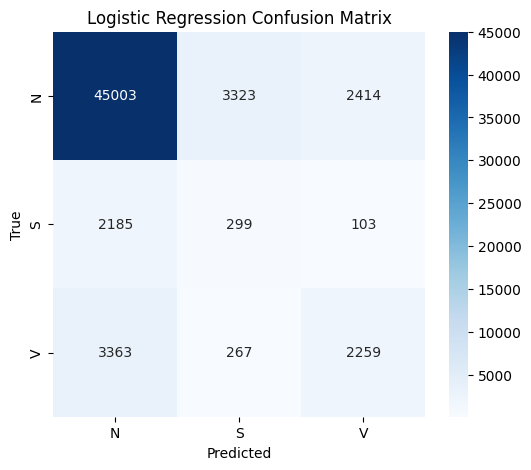


MODEL: Random Forest

Accuracy: 0.8680
              precision    recall  f1-score   support

           N       0.93      0.92      0.92     50740
           S       0.17      0.01      0.02      2587
           V       0.53      0.80      0.64      5889

    accuracy                           0.87     59216
   macro avg       0.55      0.58      0.53     59216
weighted avg       0.86      0.87      0.86     59216



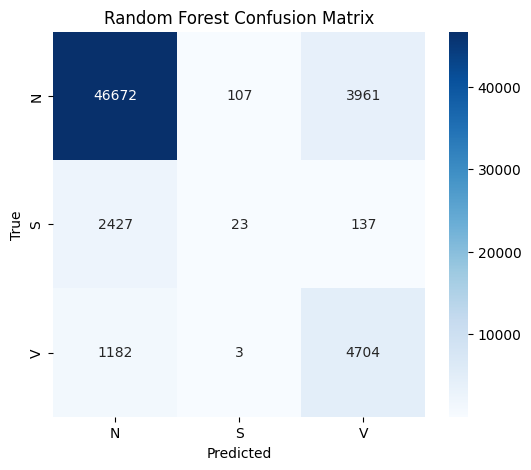


MODEL: KNN

Accuracy: 0.7281
              precision    recall  f1-score   support

           N       0.92      0.75      0.83     50740
           S       0.04      0.11      0.06      2587
           V       0.45      0.81      0.58      5889

    accuracy                           0.73     59216
   macro avg       0.47      0.55      0.49     59216
weighted avg       0.84      0.73      0.77     59216



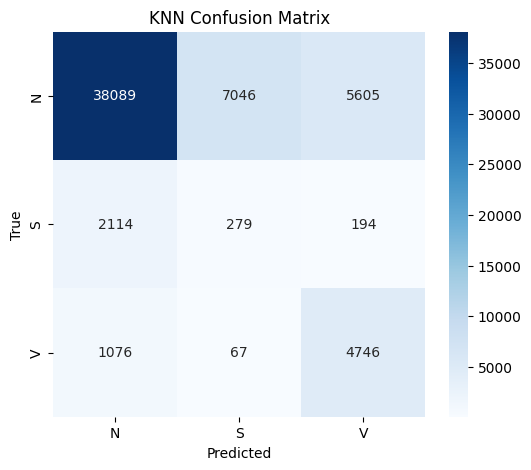


MODEL: Linear SVM

Accuracy: 0.8237
              precision    recall  f1-score   support

           N       0.89      0.91      0.90     50740
           S       0.08      0.11      0.09      2587
           V       0.58      0.39      0.47      5889

    accuracy                           0.82     59216
   macro avg       0.52      0.47      0.49     59216
weighted avg       0.83      0.82      0.82     59216



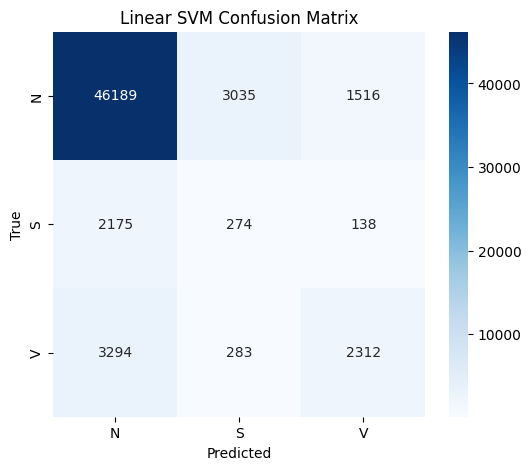


MODEL: Decision Tree

Accuracy: 0.7917
              precision    recall  f1-score   support

           N       0.92      0.83      0.88     50740
           S       0.06      0.04      0.05      2587
           V       0.38      0.75      0.51      5889

    accuracy                           0.79     59216
   macro avg       0.45      0.54      0.48     59216
weighted avg       0.83      0.79      0.80     59216



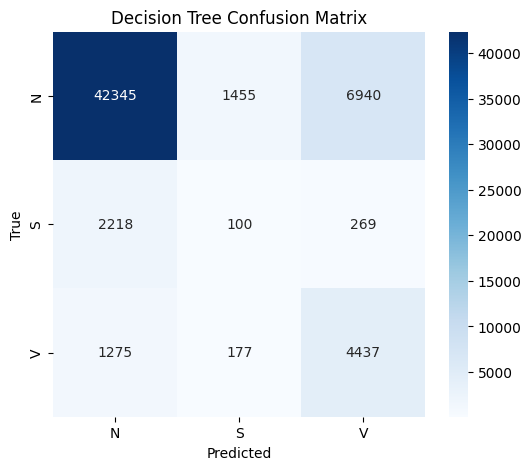


MODEL: Small Neural Network

Accuracy: 0.7546
              precision    recall  f1-score   support

           N       0.93      0.77      0.85     50740
           S       0.09      0.11      0.10      2587
           V       0.37      0.89      0.52      5889

    accuracy                           0.75     59216
   macro avg       0.46      0.59      0.49     59216
weighted avg       0.84      0.75      0.78     59216



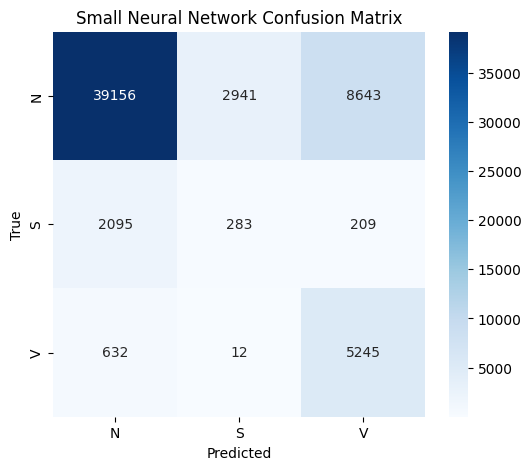

In [17]:
baseline_results = {}

print("\n\n==============================")
print("BASELINE MODELS")
print("==============================")

evaluate_models(
    X_train_base_balanced,
    y_train_base_balanced,
    X_test_base,
    y_test_base_enc,
    baseline_results
)


Train Feature Models



FEATURE MODELS

MODEL: Logistic Regression

Accuracy: 0.7562
              precision    recall  f1-score   support

           N       0.95      0.77      0.85     50740
           S       0.14      0.30      0.20      2587
           V       0.40      0.88      0.55      5889

    accuracy                           0.76     59216
   macro avg       0.50      0.65      0.53     59216
weighted avg       0.86      0.76      0.79     59216



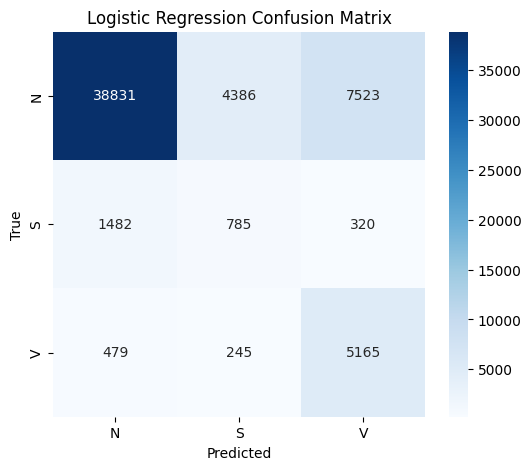


MODEL: Random Forest

Accuracy: 0.9013
              precision    recall  f1-score   support

           N       0.93      0.96      0.95     50740
           S       0.29      0.01      0.03      2587
           V       0.67      0.81      0.74      5889

    accuracy                           0.90     59216
   macro avg       0.63      0.59      0.57     59216
weighted avg       0.88      0.90      0.88     59216



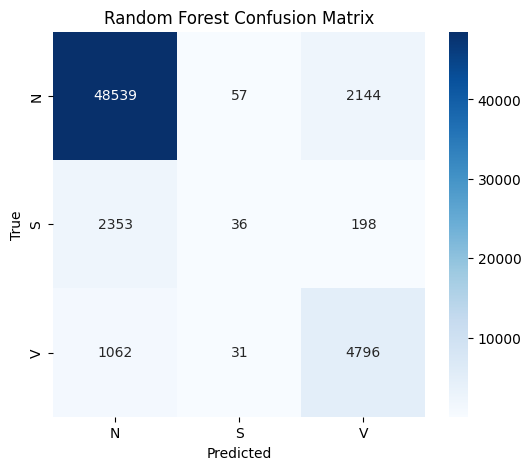


MODEL: KNN

Accuracy: 0.8108
              precision    recall  f1-score   support

           N       0.95      0.83      0.89     50740
           S       0.19      0.40      0.26      2587
           V       0.51      0.81      0.63      5889

    accuracy                           0.81     59216
   macro avg       0.55      0.68      0.59     59216
weighted avg       0.88      0.81      0.83     59216



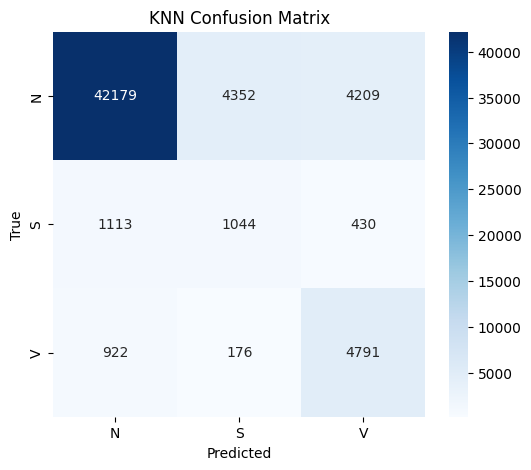


MODEL: Linear SVM

Accuracy: 0.8233
              precision    recall  f1-score   support

           N       0.95      0.84      0.90     50740
           S       0.16      0.29      0.21      2587
           V       0.53      0.88      0.66      5889

    accuracy                           0.82     59216
   macro avg       0.55      0.67      0.59     59216
weighted avg       0.88      0.82      0.84     59216



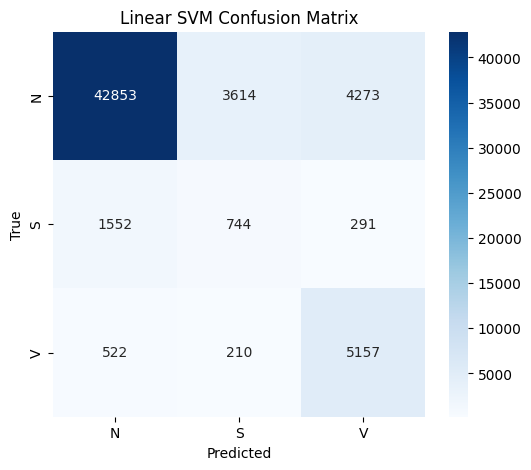


MODEL: Decision Tree

Accuracy: 0.8239
              precision    recall  f1-score   support

           N       0.94      0.87      0.90     50740
           S       0.12      0.18      0.14      2587
           V       0.51      0.75      0.60      5889

    accuracy                           0.82     59216
   macro avg       0.52      0.60      0.55     59216
weighted avg       0.86      0.82      0.84     59216



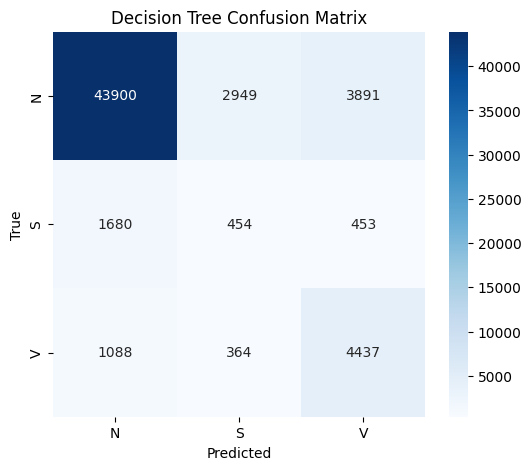


MODEL: Small Neural Network

Accuracy: 0.8233
              precision    recall  f1-score   support

           N       0.95      0.85      0.90     50740
           S       0.10      0.14      0.11      2587
           V       0.52      0.87      0.65      5889

    accuracy                           0.82     59216
   macro avg       0.52      0.62      0.55     59216
weighted avg       0.87      0.82      0.84     59216



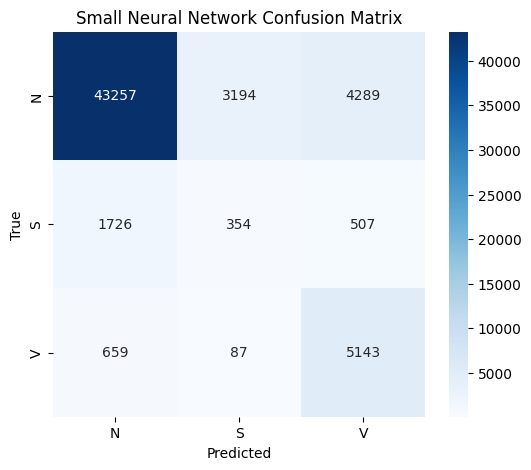

In [18]:
feature_results = {}

print("\n\n==============================")
print("FEATURE MODELS")
print("==============================")

evaluate_models(
    X_train_feat_balanced,
    y_train_feat_balanced,
    X_test_feat,
    y_test_feat_enc,
    feature_results
)

CNN Baseline Input Preparation

In [19]:
X_train_base_cnn = X_train_base_balanced.reshape(
    X_train_base_balanced.shape[0],
    X_train_base_balanced.shape[1],
    1
)

X_test_base_cnn = X_test_base.reshape(
    X_test_base.shape[0],
    X_test_base.shape[1],
    1
)

CNN Feature Input Preparation

In [20]:
X_train_feat_cnn = X_train_feat_balanced.reshape(
    X_train_feat_balanced.shape[0],
    X_train_feat_balanced.shape[1],
    1
)

X_test_feat_cnn = X_test_feat.reshape(
    X_test_feat.shape[0],
    X_test_feat.shape[1],
    1
)

CNN Model Function

In [21]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

def create_cnn_model(input_shape):

    model = Sequential([

        Conv1D(
            32,
            kernel_size=5,
            activation='relu',
            input_shape=input_shape
        ),

        BatchNormalization(),

        MaxPooling1D(pool_size=2),

        Conv1D(
            64,
            kernel_size=5,
            activation='relu'
        ),

        BatchNormalization(),

        MaxPooling1D(pool_size=2),

        Flatten(),

        Dense(128, activation='relu'),

        Dropout(0.5),

        Dense(3, activation='softmax')
    ])

    model.compile(

        optimizer='adam',

        loss='sparse_categorical_crossentropy',

        metrics=['accuracy']
    )

    return model

Train CNN Baseline

In [22]:
cnn_baseline = create_cnn_model(
    (X_train_base_cnn.shape[1], 1)
)

history_base = cnn_baseline.fit(

    X_train_base_cnn,
    y_train_base_balanced,

    epochs=15,

    batch_size=64,

    validation_split=0.2,

    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
1489/1489 ━━━━━━━━━━━━━━━━━━━━ 62s 40ms/step - accuracy: 0.9660 - loss: 0.1008 - val_accuracy: 0.9956 - val_loss: 0.0100
Epoch 2/15
1489/1489 ━━━━━━━━━━━━━━━━━━━━ 60s 41ms/step - accuracy: 0.9918 - loss: 0.0273 - val_accuracy: 0.9979 - val_loss: 0.0079
Epoch 3/15
1489/1489 ━━━━━━━━━━━━━━━━━━━━ 59s 40ms/step - accuracy: 0.9936 - loss: 0.0221 - val_accuracy: 0.9984 - val_loss: 0.0063
Epoch 4/15
1489/1489 ━━━━━━━━━━━━━━━━━━━━ 62s 41ms/step - accuracy: 0.9955 - loss: 0.0143 - val_accuracy: 0.9984 - val_loss: 0.0048
Epoch 5/15
1489/1489 ━━━━━━━━━━━━━━━━━━━━ 59s 40ms/step - accuracy: 0.9958 - loss: 0.0131 - val_accuracy: 0.9990 - val_loss: 0.0038
Epoch 6/15
1489/1489 ━━━━━━━━━━━━━━━━━━━━ 83s 40ms/step - accuracy: 0.9965 - loss: 0.0124 - val_accuracy: 0.9995 - val_loss: 0.0040
Epoch 7/15
1489/1489 ━━━━━━━━━━━━━━━━━━━━ 58s 39ms/step - accuracy: 0.9969 - loss: 0.0092 - val_accuracy: 0.9998 - val_loss: 3.2797e-04
Epoch 8/15
1489/1489 ━━━━━━━━━━━━━━━━━━━━ 59s 40ms/step - accuracy: 0.99

Evaluate CNN Baseline

In [23]:
y_pred_prob = cnn_baseline.predict(X_test_base_cnn)

y_pred = np.argmax(y_pred_prob, axis=1)

report = classification_report(
    y_test_base_enc,
    y_pred,
    target_names=le.classes_,
    output_dict=True
)

cnn_baseline_results = {

    "accuracy": accuracy_score(
        y_test_base_enc,
        y_pred
    ),

    "macro_precision": precision_score(
        y_test_base_enc,
        y_pred,
        average='macro'
    ),

    "macro_recall": recall_score(
        y_test_base_enc,
        y_pred,
        average='macro'
    ),

    "macro_f1": f1_score(
        y_test_base_enc,
        y_pred,
        average='macro'
    ),

    "class_s_recall": report['S']['recall'],

    "class_v_recall": report['V']['recall']
}

1851/1851 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step


Train CNN + ECG Features

In [24]:
cnn_feature = create_cnn_model(
    (X_train_feat_cnn.shape[1], 1)
)

history_feat = cnn_feature.fit(

    X_train_feat_cnn,
    y_train_feat_balanced,

    epochs=15,

    batch_size=64,

    validation_split=0.2,

    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
1491/1491 ━━━━━━━━━━━━━━━━━━━━ 63s 41ms/step - accuracy: 0.9827 - loss: 0.0568 - val_accuracy: 0.9899 - val_loss: 0.0304
Epoch 2/15
1491/1491 ━━━━━━━━━━━━━━━━━━━━ 81s 40ms/step - accuracy: 0.9939 - loss: 0.0194 - val_accuracy: 0.9968 - val_loss: 0.0148
Epoch 3/15
1491/1491 ━━━━━━━━━━━━━━━━━━━━ 61s 41ms/step - accuracy: 0.9953 - loss: 0.0150 - val_accuracy: 0.9958 - val_loss: 0.0153
Epoch 4/15
1491/1491 ━━━━━━━━━━━━━━━━━━━━ 59s 40ms/step - accuracy: 0.9967 - loss: 0.0121 - val_accuracy: 0.9987 - val_loss: 0.0044
Epoch 5/15
1491/1491 ━━━━━━━━━━━━━━━━━━━━ 84s 41ms/step - accuracy: 0.9973 - loss: 0.0090 - val_accuracy: 0.9949 - val_loss: 0.0274
Epoch 6/15
1491/1491 ━━━━━━━━━━━━━━━━━━━━ 59s 40ms/step - accuracy: 0.9970 - loss: 0.0095 - val_accuracy: 0.9990 - val_loss: 0.0139
Epoch 7/15
1491/1491 ━━━━━━━━━━━━━━━━━━━━ 59s 40ms/step - accuracy: 0.9979 - loss: 0.0078 - val_accuracy: 0.9996 - val_loss: 7.5249e-04
Epoch 8/15
1491/1491 ━━━━━━━━━━━━━━━━━━━━ 83s 41ms/step - accuracy: 0.99

Evaluate CNN + ECG Features

In [25]:
y_pred_prob = cnn_feature.predict(X_test_feat_cnn)

y_pred = np.argmax(y_pred_prob, axis=1)

report = classification_report(
    y_test_feat_enc,
    y_pred,
    target_names=le.classes_,
    output_dict=True
)

cnn_feature_results = {

    "accuracy": accuracy_score(
        y_test_feat_enc,
        y_pred
    ),

    "macro_precision": precision_score(
        y_test_feat_enc,
        y_pred,
        average='macro'
    ),

    "macro_recall": recall_score(
        y_test_feat_enc,
        y_pred,
        average='macro'
    ),

    "macro_f1": f1_score(
        y_test_feat_enc,
        y_pred,
        average='macro'
    ),

    "class_s_recall": report['S']['recall'],

    "class_v_recall": report['V']['recall']
}

1851/1851 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step


CNN Comparison Table

In [27]:
rows = []
rows.append({

    "Model Variant": "CNN (Baseline)",

    "Feature Type": "Raw waveform",

    "Accuracy": cnn_baseline_results["accuracy"],

    "Macro Precision": cnn_baseline_results["macro_precision"],

    "Macro Recall": cnn_baseline_results["macro_recall"],

    "Macro F1": cnn_baseline_results["macro_f1"],

    "Class S Recall": cnn_baseline_results["class_s_recall"],

    "Class V Recall": cnn_baseline_results["class_v_recall"]
})

rows.append({

    "Model Variant": "CNN + ECG Features",

    "Feature Type": "RR + QRS + amplitude",

    "Accuracy": cnn_feature_results["accuracy"],

    "Macro Precision": cnn_feature_results["macro_precision"],

    "Macro Recall": cnn_feature_results["macro_recall"],

    "Macro F1": cnn_feature_results["macro_f1"],

    "Class S Recall": cnn_feature_results["class_s_recall"],

    "Class V Recall": cnn_feature_results["class_v_recall"]
})

CNN Confusion Matrix

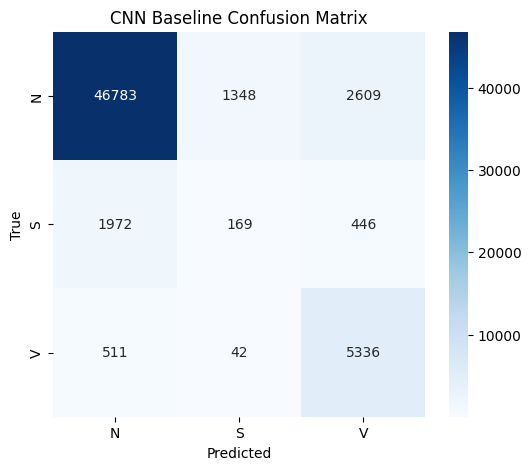

In [28]:
cm = confusion_matrix(
    y_test_base_enc,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("CNN Baseline Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("True")

plt.show()

Final Summary

In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D
from tensorflow.keras.layers import Flatten, Dense, Dropout

def build_cnn(input_shape, num_classes):

    model = Sequential([

        Conv1D(32, 5, activation='relu', input_shape=input_shape),
        MaxPooling1D(2),

        Conv1D(64, 5, activation='relu'),
        MaxPooling1D(2),

        Conv1D(128, 3, activation='relu'),
        MaxPooling1D(2),

        Flatten(),

        Dense(128, activation='relu'),
        Dropout(0.5),

        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

Final Comparison Table

In [34]:
rows = []

# =====================================================
# BASELINE MODELS
# =====================================================

for model_name, metrics in baseline_results.items():

    rows.append({

        "Model Variant": f"{model_name} (Baseline)",

        "Feature Type": "Raw waveform",

        "Accuracy": metrics["accuracy"],

        "Macro Precision": metrics["macro_precision"],

        "Macro Recall": metrics["macro_recall"],

        "Macro F1": metrics["macro_f1"]
    })

# =====================================================
# FEATURE MODELS
# =====================================================

for model_name, metrics in feature_results.items():

    rows.append({

        "Model Variant": f"{model_name} + ECG Features",

        "Feature Type": "RR + QRS + amplitude",

        "Accuracy": metrics["accuracy"],

        "Macro Precision": metrics["macro_precision"],

        "Macro Recall": metrics["macro_recall"],

        "Macro F1": metrics["macro_f1"]
    })

# =====================================================
# CNN RESULTS
# =====================================================

rows.append({

    "Model Variant": "CNN (Baseline)",

    "Feature Type": "Raw waveform",

    "Accuracy": cnn_baseline_results["accuracy"],

    "Macro Precision": cnn_baseline_results["macro_precision"],

    "Macro Recall": cnn_baseline_results["macro_recall"],

    "Macro F1": cnn_baseline_results["macro_f1"]
})

rows.append({

    "Model Variant": "CNN + ECG Features",

    "Feature Type": "RR + QRS + amplitude",

    "Accuracy": cnn_feature_results["accuracy"],

    "Macro Precision": cnn_feature_results["macro_precision"],

    "Macro Recall": cnn_feature_results["macro_recall"],

    "Macro F1": cnn_feature_results["macro_f1"]
})

# =====================================================
# CREATE TABLE
# =====================================================

comparison_table = pd.DataFrame(rows)

comparison_table = comparison_table.round(4)

print("\n====================================")
print("FINAL MODEL COMPARISON")
print("====================================")

display(comparison_table)


FINAL MODEL COMPARISON


,Model Variant,Feature Type,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Logistic Regression (Baseline),Raw waveform,0.8032,0.4800,0.4620,0.4682
1,Random Forest (Baseline),Raw waveform,0.8680,0.5452,0.5758,0.5271
2,KNN (Baseline),Raw waveform,0.7281,0.4702,0.5548,0.4871
3,Linear SVM (Baseline),Raw waveform,0.8237,0.5178,0.4696,0.4867
4,Decision Tree (Baseline),Raw waveform,0.7917,0.4542,0.5422,0.4764
5,Small Neural Network (Baseline),Raw waveform,0.7546,0.4648,0.5906,0.4892
6,Logistic Regression + ECG Features,RR + QRS + amplitude,0.7562,0.4980,0.6486,0.5304
7,Random Forest + ECG Features,RR + QRS + amplitude,0.9013,0.6322,0.5950,0.5694
8,KNN + ECG Features,RR + QRS + amplitude,0.8108,0.5498,0.6828,0.5899
9,Linear SVM + ECG Features,RR + QRS + amplitude,0.8233,0.5491,0.6693,0.5882
